# Convolution Tutorial Series — Part 5: Dilations

In [1]:
from IPython.display import Video

video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part5-supportvideo/DilationTutorial.mp4'

Video(video_path, width=750, height=450, embed=True)

**Goal:** Understand the `dilations` attribute, this is the last attribute you can set in the ONNX `Conv` function. This is the fifth episode dedicated to the Conv operator, covering all its attributes:
- **Part 1:** [Kernel Size and Bias](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-1)
- **Part 2:** [Padding](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-2)
- **Part 3:** [Stride](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-3)
- **Part 4:** [Groups](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-4)
- **Part 5:** Dilations (this notebook)

We will explain these as simply as possible, using ARC Task 314 as an example.

**Score formula:** `Points = max(1.0, 25.0 - log(Mem_bytes + Params))`

**Our result:** Mem=0, Params=100, **20.395 points**

---

In [2]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 846.4 kB/s eta 0:00:00


# 1. Task 314

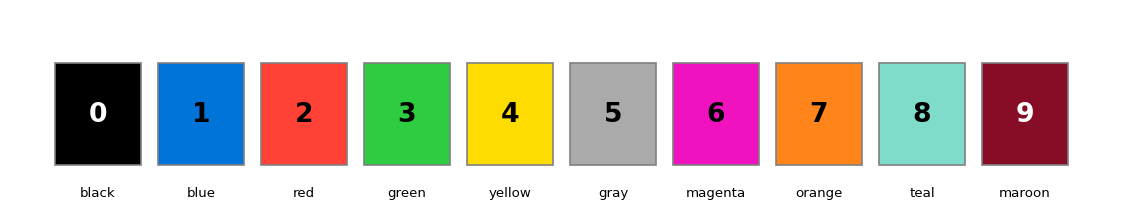

In [3]:
import json, warnings, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime as ort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

arc_colors = [
    '#000000',  # 0: black
    '#0074D9',  # 1: blue
    '#FF4136',  # 2: red
    '#2ECC40',  # 3: green
    '#FFDC00',  # 4: yellow
    '#AAAAAA',  # 5: gray
    '#F012BE',  # 6: magenta
    '#FF851B',  # 7: orange
    '#7FDBCA',  # 8: teal
    '#870C25',  # 9: maroon
]
color_names = ['black','blue','red','green','yellow','gray','magenta','orange','teal','maroon']

def plot_arc_grid(grid, ax, title=''):
    H, W = len(grid), len(grid[0])
    img = np.zeros((H, W, 3), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            hex_c = arc_colors[grid[r][c]].lstrip('#')
            img[r,c] = [int(hex_c[i:i+2], 16) for i in (0, 2, 4)]
    ax.imshow(img, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10, fontweight='bold')
    for r in range(H+1): ax.axhline(r-0.5, color='gray', lw=0.5, alpha=0.3)
    for c in range(W+1): ax.axvline(c-0.5, color='gray', lw=0.5, alpha=0.3)

fig, ax = plt.subplots(figsize=(12, 2))
for i, (c, nm) in enumerate(zip(arc_colors, color_names)):
    ax.add_patch(patches.Rectangle((i*1.2, 0), 1, 1, facecolor=c, edgecolor='gray', lw=1))
    ax.text(i*1.2+0.5, 0.5, str(i), ha='center', va='center', fontsize=16, fontweight='bold',
            color='white' if i in [0,9] else 'black')
    ax.text(i*1.2+0.5, -0.2, nm, ha='center', va='top', fontsize=8)
ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.3, 1.5)
ax.axis('off')
plt.show()

The input is an 8×8 grid divided by full rows and columns of zeros (at indices 2 and 5) into a 3×3 layout of 2×2 blocks. Most cells are Blue (1), with some special colors appearing at specific positions.

The rules are:
1. **Propagation:** Any special color (not 0 or 1) that appears in a block is copied 3 steps away to the equivalent position in adjacent blocks along the same row or column.
2. **Persistence:** The original colored pixels must stay.

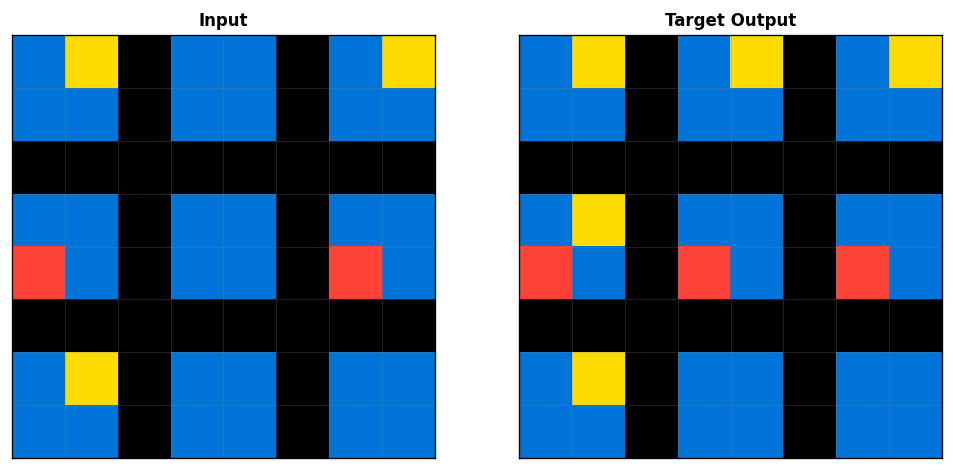

Notice: Yellow (4) and Red (2) propagate 3 steps to adjacent blocks.
The center block inherits the special colors from its neighbors.


In [4]:
with open('/kaggle/input/competitions/neurogolf-2026/task314.json') as f:
    task = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_arc_grid(task['train'][0]['input'], axes[0], 'Input')
plot_arc_grid(task['train'][0]['output'], axes[1], 'Target Output')
plt.show()

print("Notice: Yellow (4) and Red (2) propagate 3 steps to adjacent blocks.")
print("The center block inherits the special colors from its neighbors.")

# 2. Dilations

In the previous notebooks, we always used adjacent pixels — a 3×3 kernel with `dilations=[1, 1]` looks at the 8 neighbors immediately around the center pixel. But what happens when the rule requires interacting with pixels that are 3 steps away?

We could use a 7×7 kernel, but that would cost $10 \times 10 \times 7 \times 7 = 4900$ weights. That's a lot of parameters!

## The Dilation Trick

Dilation inserts `d−1` "holes" between kernel elements. The kernel still has the same number of weights (9 for 3×3), but it now covers a larger area.

### Effective Receptive Field

The area covered by a dilated kernel is called the **effective receptive field**:

$$k_{\text{eff}} = (k - 1) \cdot d + 1$$

Where $k$ is the kernel size and $d$ is the dilation factor.

### Asymmetric Dilations

Dilations can be different for height and width: `dilations=[dH, dW]`. This gives different effective receptive fields for rows and columns.

| dilations | k_eff (H×W) | What it sees |
|-----------|-------------|--------------|
| [1, 1] | 3×3 | Adjacent pixels only (default) |
| [2, 2] | 5×5 | Every other pixel |
| [2, 3] | 5×7 | Different spacing for rows vs cols |
| [3, 3] | 7×7 | Pixels 3 steps apart (used in Task 314) |

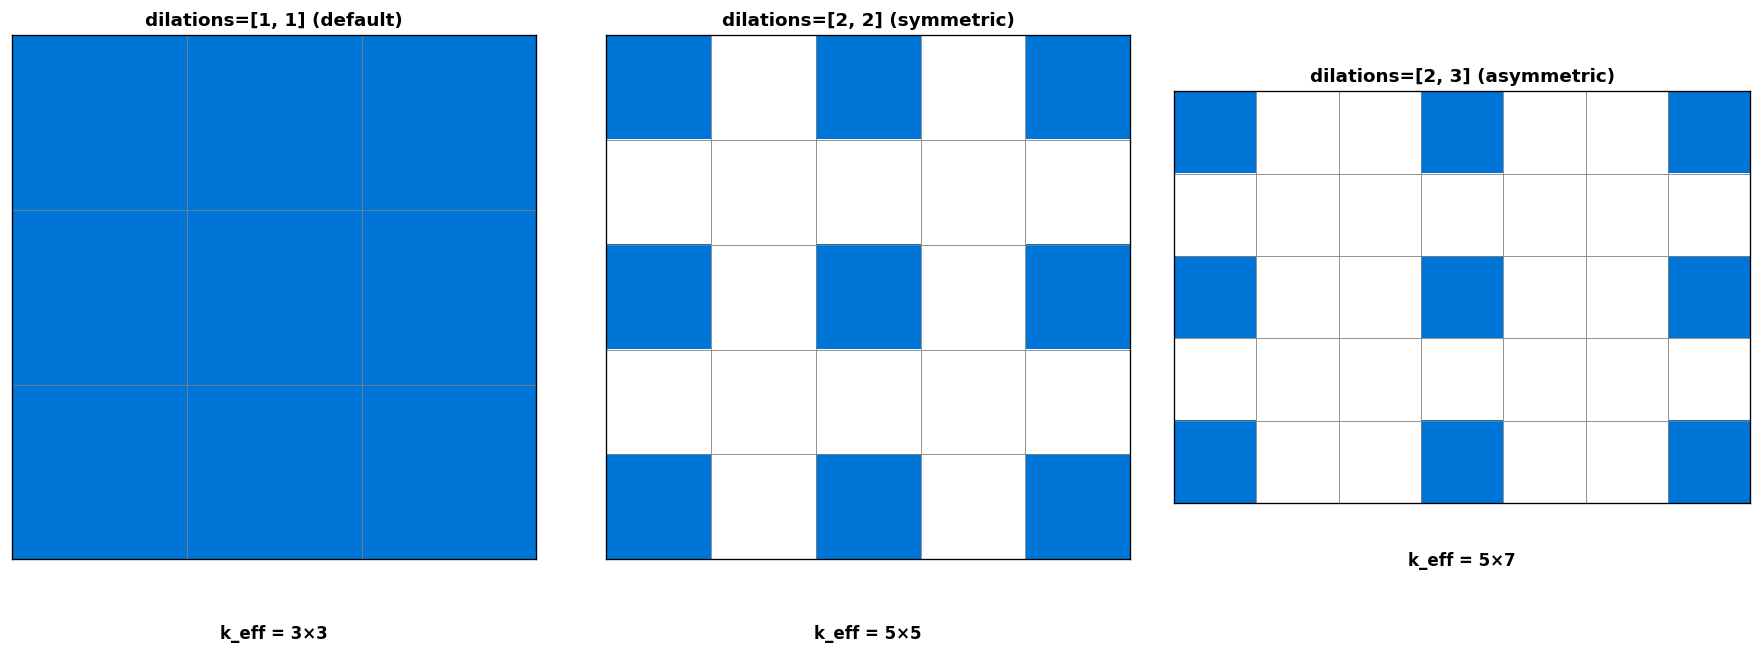

Blue squares = kernel positions. White squares = holes (ignored).
Each case still has exactly 9 weights — but they reach much farther!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_i, (title, (d_h, d_w)) in enumerate([
    ('dilations=[1, 1] (default)', [1, 1]),
    ('dilations=[2, 2] (symmetric)', [2, 2]),
    ('dilations=[2, 3] (asymmetric)', [2, 3]),
]):
    ax = axes[ax_i]
    kH_eff = (3 - 1) * d_h + 1
    kW_eff = (3 - 1) * d_w + 1
    grid = np.ones((kH_eff, kW_eff, 3))
    for i in range(3):
        for j in range(3):
            grid[i*d_h, j*d_w] = [0, 0.46, 0.85]
    ax.imshow(grid, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight='bold')
    for r in range(kH_eff+1): ax.axhline(r-0.5, color='gray', lw=0.5)
    for c in range(kW_eff+1): ax.axvline(c-0.5, color='gray', lw=0.5)
    ax.text(0.5, -0.15, f'k_eff = {kH_eff}\u00d7{kW_eff}', transform=ax.transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Blue squares = kernel positions. White squares = holes (ignored).")
print("Each case still has exactly 9 weights — but they reach much farther!")

# 3. Depthwise Dilated Convolution for Task 314

Now let's apply this to Task 314. The grid has a repeating block structure where blocks are 3 steps apart. A 3×3 kernel with `dilations=[3, 3]` has an effective receptive field of $7\times7$, reaching exactly 3 steps in each direction:

| Offset | Reaches |
|--------|---------|
| (0, 0) | Same pixel (identity) |
| (0, ±3) | Left/right adjacent block |
| (±3, 0) | Top/bottom adjacent block |
| (±3, ±3) | Diagonal block |

We also use `group=10` (depthwise) so each color channel processes independently, saving massive parameter counts. We actually train the single convolution network to get the weight but is intuitive that is possible to design such a network.


### Parameter Comparison

| Approach | Weight Shape | Weights | Biases | Total |
|----------|-------------|---------|--------|-------|
| Group=1, no dilation | [10, 10, 7, 7] | 4900 | 10 | 4910 |
| Group=10, no dilation | [10, 1, 7, 7] | 490 | 10 | 500 |
| **Group=10, dilation=3** | [10, 1, 3, 3] | 90 | 10 | **100** |

In [6]:
def create_task314_model():
    W = np.zeros((10, 1, 3, 3), dtype=np.float32)
    W[0, 0, 1, 1] = 0.01999999955
    W[1, 0, 0, 0] = -0.01999999955
    W[1, 0, 0, 1] = 0.01999999955
    W[1, 0, 0, 2] = -0.01999999955
    W[1, 0, 1, 0] = 0.01999999955
    W[1, 0, 1, 1] = 0.03999999911
    W[1, 0, 1, 2] = 0.01999999955
    W[1, 0, 2, 0] = -0.01999999955
    W[1, 0, 2, 1] = 0.01999999955
    W[1, 0, 2, 2] = -0.01999999955
    W[2, 0, 0, 1] = 0.01999999955
    W[2, 0, 1, 0] = 0.01999999955
    W[2, 0, 1, 1] = 0.03999999911
    W[2, 0, 1, 2] = 0.01999999955
    W[2, 0, 2, 1] = 0.01999999955
    W[3, 0, 0, 1] = 0.01999999955
    W[3, 0, 1, 0] = 0.01999999955
    W[3, 0, 1, 1] = 0.03999999911
    W[3, 0, 1, 2] = 0.01999999955
    W[3, 0, 2, 1] = 0.01999999955
    W[4, 0, 0, 1] = 0.01999999955
    W[4, 0, 1, 0] = 0.01999999955
    W[4, 0, 1, 1] = 0.03999999911
    W[4, 0, 1, 2] = 0.01999999955
    W[4, 0, 2, 1] = 0.01999999955
    W[5, 0, 0, 1] = 0.01999999955
    W[5, 0, 1, 0] = 0.01999999955
    W[5, 0, 1, 1] = 0.03999999911
    W[5, 0, 1, 2] = 0.01999999955
    W[5, 0, 2, 1] = 0.01999999955
    W[6, 0, 0, 1] = 0.01999999955
    W[6, 0, 1, 0] = 0.01999999955
    W[6, 0, 1, 1] = 0.03999999911
    W[6, 0, 1, 2] = 0.01999999955
    W[6, 0, 2, 1] = 0.01999999955
    W[7, 0, 0, 1] = 0.01999999955
    W[7, 0, 1, 0] = 0.01999999955
    W[7, 0, 1, 1] = 0.03999999911
    W[7, 0, 1, 2] = 0.01999999955
    W[7, 0, 2, 1] = 0.01999999955
    W[8, 0, 0, 1] = 0.01999999955
    W[8, 0, 1, 0] = 0.01999999955
    W[8, 0, 1, 1] = 0.03999999911
    W[8, 0, 1, 2] = 0.01999999955
    W[8, 0, 2, 1] = 0.01999999955
    W[9, 0, 0, 1] = 0.01999999955
    W[9, 0, 1, 0] = 0.01999999955
    W[9, 0, 1, 1] = 0.03999999911
    W[9, 0, 1, 2] = 0.01999999955
    W[9, 0, 2, 1] = 0.01999999955
    
    B = np.array([-0.01, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03], dtype=np.float32)


    X = helper.make_tensor_value_info("input", TensorProto.FLOAT, [1, 10, 30, 30])
    Y = helper.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, 30])

    node = helper.make_node("Conv", ["input", "W", "B"], ["output"],
                            kernel_shape=[3, 3], pads=[3, 3, 3, 3],
                            group=10, dilations=[3, 3])

    graph = helper.make_graph([node], "task314", [X], [Y], initializer=[
        numpy_helper.from_array(W, name="W"),
        numpy_helper.from_array(B, name="B"),
    ])

    model = helper.make_model(graph, opset_imports=[helper.make_operatorsetid("", 11)])
    return model

model = create_task314_model()
onnx.save(model, "task314_demo.onnx")

In [7]:
from IPython.display import Video

video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part5-supportvideo/DilationTutorial.mp4'

Video(video_path, width=750, height=450, embed=True)

# 4. Running the Model
Let's run the model on all train examples and the test example.

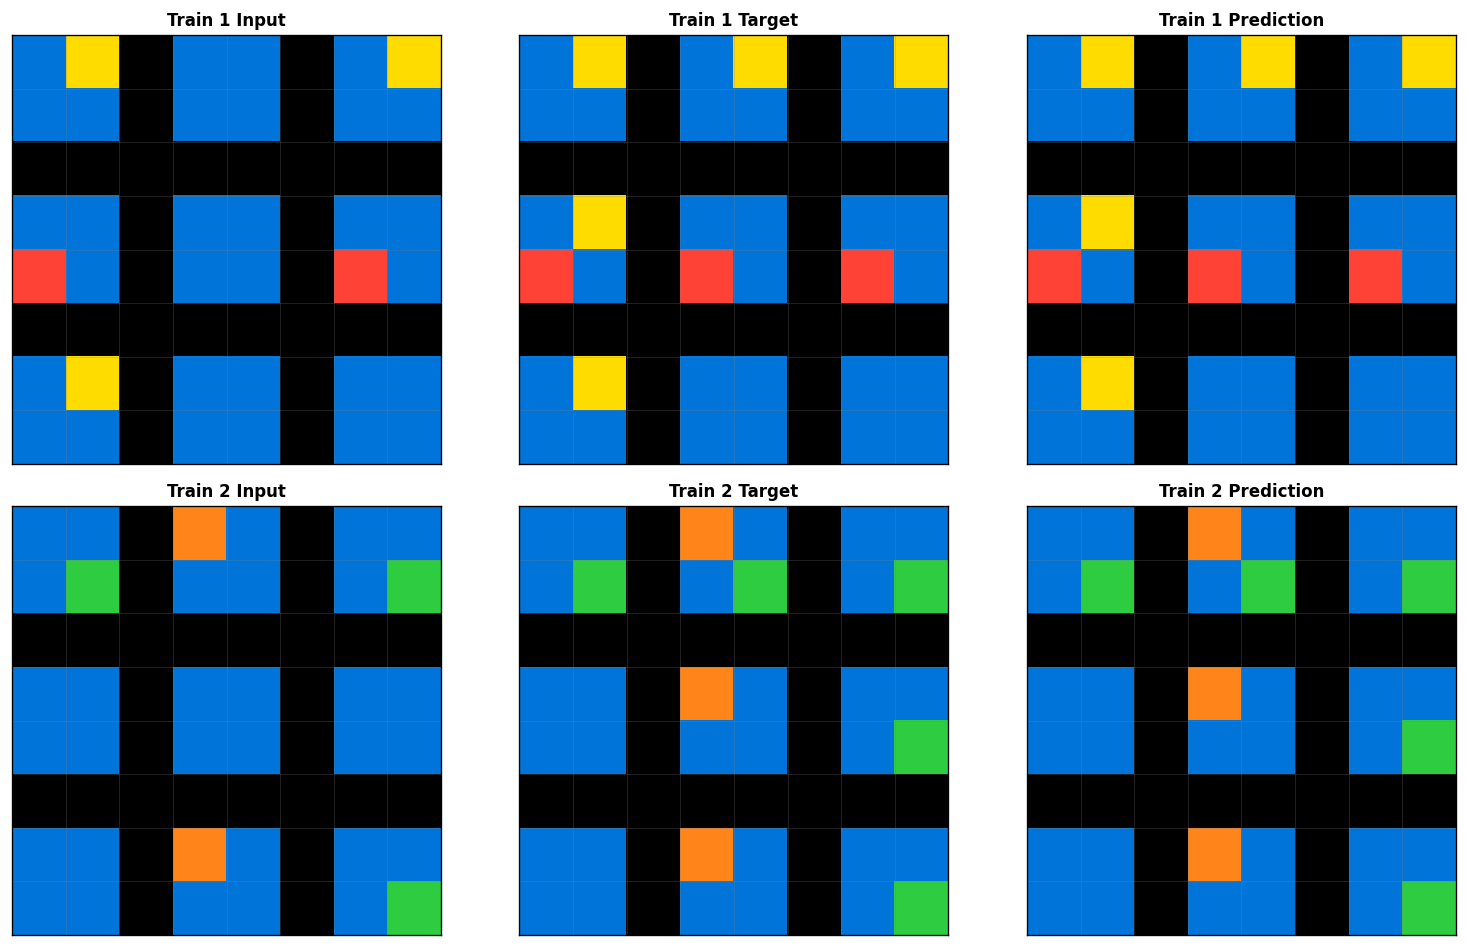

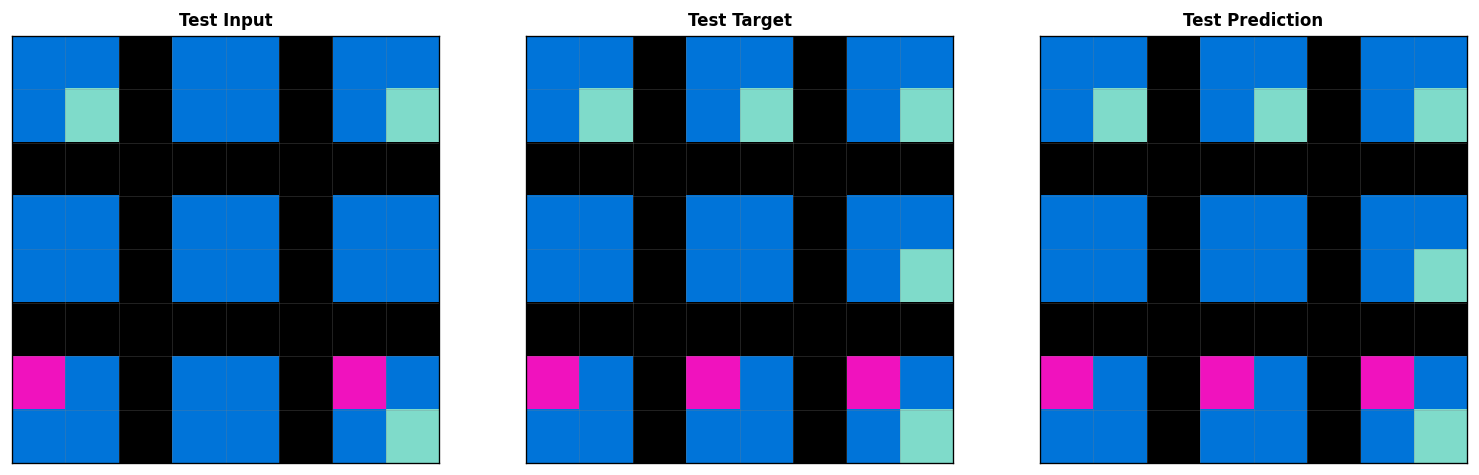

Results on ARC-AGI examples: 4 pass, 0 fail
Results on ARC-GEN examples: 262 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    90,000          100.00%     36,400    100.00%          100  100.00%     1x10x30x30  1x10x30x30
Total   _       90,000          100%        36,400    100%             100  100%        _           _

It appears to require 0 bytes + 100 params, yielding 20.395 points.

Next steps:
 * Click the link below to download task314.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially scored.



/kaggle/working/task314.onnx

In [8]:
def run_inference(grid, model_path):
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            oh[0, grid[r][c], r, c] = 1.0
    sess = ort.InferenceSession(model_path)
    out = sess.run(None, {'input': oh})[0]
    return np.argmax(out[0], axis=0)

# Test on all train examples
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i in range(2):
    inp = task['train'][i]['input']
    target = task['train'][i]['output']
    pred = run_inference(inp, 'task314_demo.onnx')
    H, W = len(inp), len(inp[0])
    plot_arc_grid(inp, axes[i, 0], f'Train {i+1} Input')
    plot_arc_grid(target, axes[i, 1], f'Train {i+1} Target')
    plot_arc_grid(pred[:H, :W], axes[i, 2], f'Train {i+1} Prediction')
plt.tight_layout()
plt.show()

# Test on test example
test_inp = task['test'][0]['input']
test_tgt = task['test'][0]['output']
test_pred = run_inference(test_inp, 'task314_demo.onnx')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_arc_grid(test_inp, axes[0], 'Test Input')
plot_arc_grid(test_tgt, axes[1], 'Test Target')
plot_arc_grid(test_pred[:len(test_inp), :len(test_inp[0])], axes[2], 'Test Prediction')
plt.tight_layout()
plt.show()

# Verify with official checker
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import verify_network
passed = verify_network(model, 314, task)

# Summary
- **Last Conv Attribute:** `dilations` is the final attribute you can set in the ONNX `Conv` operator — completing our tutorial series covering kernel_shape, bias, padding, strides, groups, and dilations.
- **Reaching Far with Few Params:** A 3×3 kernel with `dilations=[3, 3]` reaches pixels 7 steps apart using only 9 weights.
- **Effective Receptive Field:** $k_{\text{eff}} = (k - 1) \times d + 1$ — grows linearly with dilation, costs nothing in parameters.
- **Depthwise + Dilation:** Combining `group=10` with `dilations=[3, 3]` gives a model with only 100 parameters total — 91% fewer than a naive 7×7 Conv.
- **Symmetric & Asymmetric:** Dilation can be different for rows and columns (`dilations=[dH, dW]`) enabling non-square effective fields.

In [9]:
import shutil
import os
import zipfile

# --- CONFIGURATION ---
SOURCE_FOLDER = '/kaggle/input/datasets/massimilianoghiotto/neurogolf2026-7116/'
OUTPUT_ZIP = '/kaggle/working/submission.zip'

# Package the ZIP (Ensuring files are at the root)
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SOURCE_FOLDER):
        for file in files:
            if file.endswith('.onnx'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, SOURCE_FOLDER))

# Acknowledgments
Big shoutout to everyone who shared ideas and notebooks 
@cdeotte, @kojimar, @konbu17, @mirzayasirabdullah07, @nadeembinshajahan, @octaviograu, @qinghchen, @rauffauzanrambe, @seddiktrk, @yash9439 and many more that I might have missed.

### **This is the best that we are able to do for the moment, if anyone has any suggestion, please write it in the comments, we are happy to have some brainstorning between people.**